# LOAD DATA

In [4]:
import pandas as pd
import numpy as np
df =pd.read_csv("../data/Raw/TN_Vegetable_Price_Index_Enhanced.csv")

# NULL ANALYSIS


In [6]:
missing = (
    df.isnull()
    .sum()
    .sort_values(ascending=False)
)

missing

govt_scheme                  2194
irrigation_type              1780
record_id                       0
z_score_quantity                0
farm_price_outlier_flag         0
                             ... 
temperature_c                   0
humidity_pct                    0
shelf_life_days                 0
transport_cost_inr              0
organic_price_premium_inr       0
Length: 74, dtype: int64

# NULL PERCENTAGES

In [8]:
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_pct

record_id                    0.0
farmer_name                  0.0
vegetable_name               0.0
category                     0.0
district                     0.0
                            ... 
district_avg_retail          0.0
district_price_rank          0.0
veg_price_skewness           0.0
veg_price_kurtosis           0.0
organic_price_premium_inr    0.0
Length: 74, dtype: float64

# HANDLE NULLS

In [10]:
df.humidity_pct = df.humidity_pct.fillna(df.humidity_pct.median())

In [11]:
#df['humidity_pct'] = df['humidity_pct'].fillna(df['humidity_pct'].median())

# REMOVE DUPLICATES

In [12]:
df.drop_duplicates()

,record_id,farmer_name,vegetable_name,category,district,mandi_name,date,season,month,year,...,env_stress_index,mom_price_change_pct,seasonal_price_premium_pct,cumul_revenue_per_farmer,retail_price_bin,district_avg_retail,district_price_rank,veg_price_skewness,veg_price_kurtosis,organic_price_premium_inr
0,TN-VEG-00001,Velu Pandian,Manathakkali Keerai,Leafy,Nilgiris,Ooty Hill Market,2022-01-31,Winter,1,2022,...,-1.29,25.56,2.1782,23515273.22,60-80,101.95,9,0.6381,0.2379,0.0
1,TN-VEG-00002,Murugan Pillai,Lotus Stem,Aquatic,Nagapattinam,Coastal Mandi NGP,2023-09-15,Southwest Monsoon,9,2023,...,9.44,23.71,10.8862,38707643.06,>100,103.78,14,0.7657,0.4030,0.0
2,TN-VEG-00003,Durai Murugesan,Drumstick,Pod,Dindigul,Palani Market,2024-02-25,Winter,2,2024,...,-7.27,-10.29,-14.9507,42246756.07,80-100,102.41,11,0.5516,0.1479,0.0
3,TN-VEG-00004,Suresh Karthik,Ash Gourd,Gourd,Madurai,Mattuthavani Mandi,2022-02-12,Winter,2,2022,...,-3.93,113.07,25.2591,23316277.74,40-60,105.18,17,0.4942,0.1230,0.0
4,TN-VEG-00005,Kannan Subramanian,Banana Flower,Flower,Nilgiris,Ooty Hill Market,2021-07-27,Southwest Monsoon,7,2021,...,16.20,-38.15,-8.2327,17234230.95,60-80,101.95,9,0.5197,-0.0460,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10995,TN-VEG-10996,Chelladurai Nadar,Onion,Bulb,Dindigul,Dindigul Main Mandi,2023-07-12,Southwest Monsoon,7,2023,...,17.63,9.44,-1.9107,30946937.46,80-100,102.41,11,0.5574,-0.0338,0.0
10996,TN-VEG-10997,Lakshmi Ammal,Brinjal,Fruit-Vegetable,Namakkal,Namakkal Mandi,2023-04-03,Summer,4,2023,...,-3.29,-24.09,14.8197,32952018.17,60-80,108.85,23,0.8245,0.4729,0.0
10997,TN-VEG-10998,Suresh Karthik,Snake Gourd,Gourd,Sivagangai,Sivagangai Mandi,2020-10-03,Northeast Monsoon,10,2020,...,28.89,30.00,-0.4516,14691620.20,40-60,105.74,19,0.9898,1.5999,0.0
10998,TN-VEG-10999,Ramachandran Naidu,Ridge Gourd,Gourd,Dharmapuri,Harur Market,2021-06-04,Southwest Monsoon,6,2021,...,20.96,5.83,-2.8997,18767470.66,40-60,104.41,15,0.5345,-0.1303,0.0


# DATETIME CONVERSION

In [13]:
df['date'] = pd.to_datetime(df['date'])

# CREATE DATE FEATURES

In [20]:
df.year = df.date.dt.year
df.month = df.date.dt.month
df.day_name = df.date.dt.day_name()

In [24]:
df.day_name.head()

0      Monday
1      Friday
2      Sunday
3    Saturday
4     Tuesday
Name: date, dtype: object

# BUSINESS KPI ENGINEERING
## PROFIT MARGIN

In [26]:
df['profit_margin'] = (
    df['retail_price_inr_per_kg']
    - df['farm_price_inr_per_kg']
)

In [27]:
df.profit_margin.head()

0     47.40
1    110.19
2     55.63
3     38.14
4     41.93
Name: profit_margin, dtype: float64

## MARGIN %

In [28]:
df['margin_pct'] = (
    df['profit_margin']
    / df['farm_price_inr_per_kg']
) * 100

In [34]:
df[['vegetable_name','margin_pct']].head()

,vegetable_name,margin_pct
0,Manathakkali Keerai,238.790932
1,Lotus Stem,160.626822
2,Drumstick,182.453263
3,Ash Gourd,226.888757
4,Banana Flower,176.770658


## WASTAGE IMPACT SCORE

In [35]:
df['wastage_impact'] = (
    df['post_harvest_loss_pct']
    * df['retail_price_inr_per_kg']
)

## CORRELATION HEATMAP

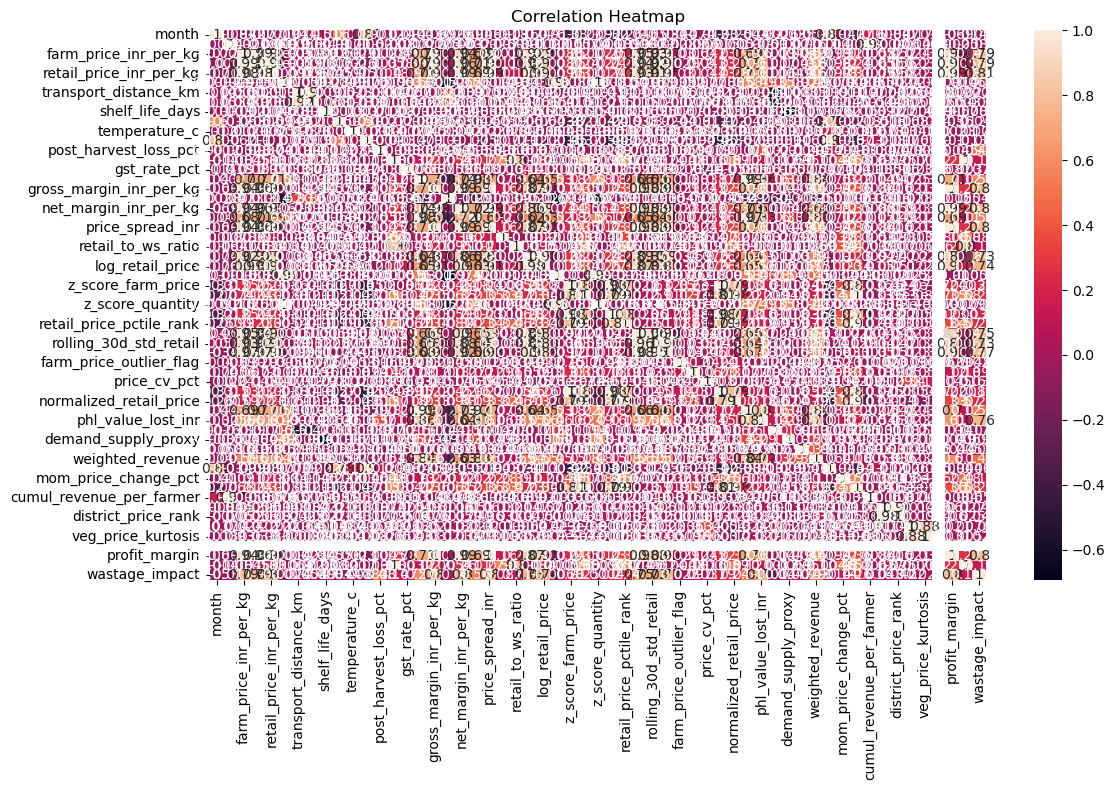

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_df = df.select_dtypes(include='number')

plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True
)

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.xticks(rotation = 90)

plt.savefig(
    "../images/Pandas_work/correlation_heatmap.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# EXPORT CLEAN DATA

In [46]:
df.to_csv("../data/Cleaned/cleaned_vegetable_analysis.csv",index=False)


# TOP DISTRICT CHART

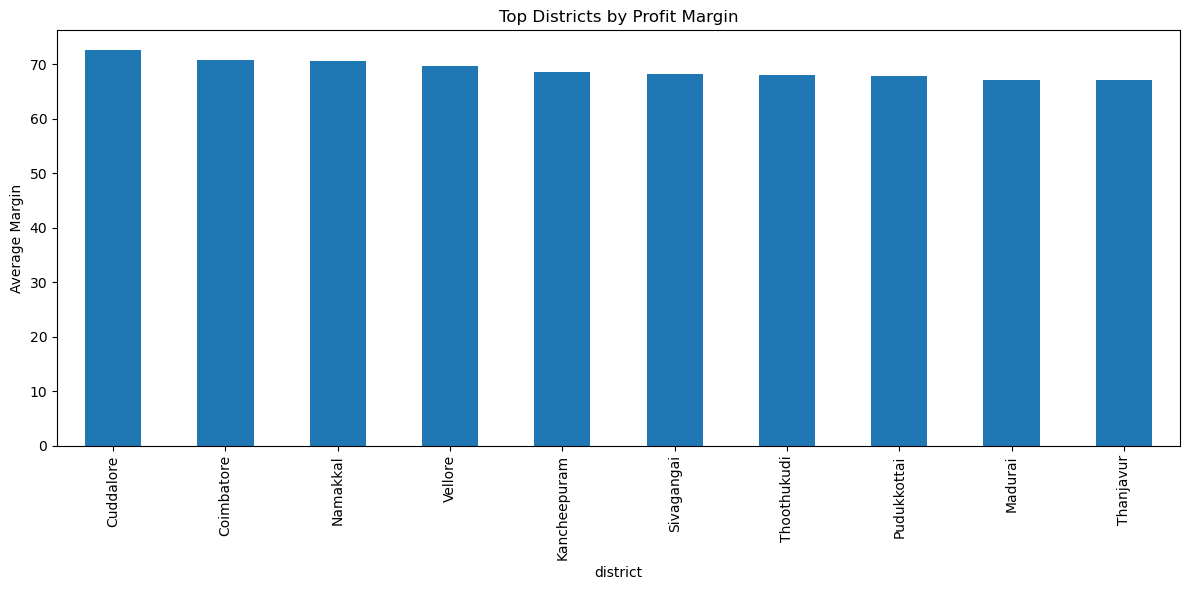

In [47]:
top_districts = (
    df.groupby('district')
    ['profit_margin']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

top_districts.plot(kind='bar')

plt.title("Top Districts by Profit Margin")

plt.ylabel("Average Margin")

plt.tight_layout()

plt.savefig(
    "../images/top_profit_districts.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()